# Indian Startup Funding — EDA (2015–2019)

**Objective:** Explore and analyze startup funding trends in India across 5 years,
covering 3,000+ deals worth $38B+.

**Dataset:** Kaggle — Indian Startup Funding  
**Tools:**   Python · Pandas · NumPy · Matplotlib · Seaborn  
**Output:**  Cleaned dataset exported as `startup_funding_final.csv`

---
## Importing Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("startup_funding_cleaned.csv")
df.head()

,Date,startup_name,industry_vertical,SubVertical,Country,City /State Location,Investors_Name,Investment_Type,Amount_in_USD,Remarks
0,20-12-2019,Lenskart,E-Commerce,Online Eyewear Shopping Portal,India,Faridabad,SoftBank Vision Fund,Series G,"23,10,00,000",No Remark
1,17-12-2019,Healthians,FoodTech,Food Solutions For Corporate,India,Bengaluru,"Paytm, NPTK, Sabre Partners and Neoplux",Series C,"1,20,00,000",No Remark
2,16-12-2019,InCred,FinTech,Non-Banking Financial Company,India,Mumbai,Undisclosed,Debt Funding,"59,00,000",No Remark
3,16-12-2019,Licious,E-Commerce,Online Meat And Seafood Ordering Startup,India,Bengaluru,Vertex Growth Fund,Series E,"3,00,00,000",No Remark
4,14-12-2019,Trell,Media & Entertainment,Experience Discovery Platform,India,Bengaluru,Ruizheng Investment,Seed Funding,"20,00,000",No Remark


---
## Setup for visualisation 

In [2]:
import warnings
warnings.filterwarnings('ignore')
# Global style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'

NAVY = "#0A174E"
GOLD = "#F5D042"

---
## Quick edits and observation in data 

In [3]:
df.index = df.index + 1

In [4]:
df = df.drop('Remarks', axis=1)
df.head(5)

,Date,startup_name,industry_vertical,SubVertical,Country,City /State Location,Investors_Name,Investment_Type,Amount_in_USD
1,20-12-2019,Lenskart,E-Commerce,Online Eyewear Shopping Portal,India,Faridabad,SoftBank Vision Fund,Series G,"23,10,00,000"
2,17-12-2019,Healthians,FoodTech,Food Solutions For Corporate,India,Bengaluru,"Paytm, NPTK, Sabre Partners and Neoplux",Series C,"1,20,00,000"
3,16-12-2019,InCred,FinTech,Non-Banking Financial Company,India,Mumbai,Undisclosed,Debt Funding,"59,00,000"
4,16-12-2019,Licious,E-Commerce,Online Meat And Seafood Ordering Startup,India,Bengaluru,Vertex Growth Fund,Series E,"3,00,00,000"
5,14-12-2019,Trell,Media & Entertainment,Experience Discovery Platform,India,Bengaluru,Ruizheng Investment,Seed Funding,"20,00,000"


In [5]:
df.shape

(3035, 9)

In [6]:
df.isnull().sum() # To get an idea of quantities of null to deal with in each column.

Date                      0
startup_name              0
industry_vertical         0
SubVertical               0
Country                   0
City /State Location      0
Investors_Name            0
Investment_Type           0
Amount_in_USD           970
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035 entries, 1 to 3035
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Date                  3035 non-null   object
 1   startup_name          3035 non-null   object
 2   industry_vertical     3035 non-null   object
 3   SubVertical           3035 non-null   object
 4   Country               3035 non-null   object
 5   City /State Location  3035 non-null   object
 6   Investors_Name        3035 non-null   object
 7   Investment_Type       3035 non-null   object
 8   Amount_in_USD         2065 non-null   object
dtypes: object(9)
memory usage: 213.5+ KB


### Assigning suitable datatype to columns and removing extra white spaces

In [8]:
df.columns = df.columns.str.strip().str.lower() # Removed unnecessary spaces from column names
df['amount_in_usd'] = df['amount_in_usd'].astype(str).str.replace(',', '')
df['amount_in_usd'] = pd.to_numeric(df['amount_in_usd'], errors='coerce')
df['date'] = pd.to_datetime(df['date'], dayfirst = 'True', errors='coerce')
df[['startup_name', 'industry_vertical', 'subvertical', 'country', 'city /state location', 'investors_name', 'investment_type']] = df[['startup_name', 'industry_vertical', 'subvertical', 'country', 'city /state location', 'investors_name', 'investment_type']].astype('string')
df['amount_in_usd']  = df['amount_in_usd'].astype('Int64')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3035 entries, 1 to 3035
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  3035 non-null   datetime64[ns]
 1   startup_name          3035 non-null   string        
 2   industry_vertical     3035 non-null   string        
 3   subvertical           3035 non-null   string        
 4   country               3035 non-null   string        
 5   city /state location  3035 non-null   string        
 6   investors_name        3035 non-null   string        
 7   investment_type       3035 non-null   string        
 8   amount_in_usd         2065 non-null   Int64         
dtypes: Int64(1), datetime64[ns](1), string(7)
memory usage: 216.5 KB


### Extracting month name and year from Date column 

In [10]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month_name() 

In [11]:
df.head(10)

,date,startup_name,industry_vertical,subvertical,country,city /state location,investors_name,investment_type,amount_in_usd,year,month
1,2019-12-20,Lenskart,E-Commerce,Online Eyewear Shopping Portal,India,Faridabad,SoftBank Vision Fund,Series G,231000000,2019,December
2,2019-12-17,Healthians,FoodTech,Food Solutions For Corporate,India,Bengaluru,"Paytm, NPTK, Sabre Partners and Neoplux",Series C,12000000,2019,December
3,2019-12-16,InCred,FinTech,Non-Banking Financial Company,India,Mumbai,Undisclosed,Debt Funding,5900000,2019,December
4,2019-12-16,Licious,E-Commerce,Online Meat And Seafood Ordering Startup,India,Bengaluru,Vertex Growth Fund,Series E,30000000,2019,December
5,2019-12-14,Trell,Media & Entertainment,Experience Discovery Platform,India,Bengaluru,Ruizheng Investment,Seed Funding,2000000,2019,December
6,2019-12-13,Rivigo,SaaS & Enterprise Tech,Logistics Services and Solutions,India,Gurugram,"SAIF Partners, Spring Canter Investment Ltd.",Series F,20000000,2019,December
7,2019-12-12,Ecozen,SaaS & Enterprise Tech,Agritech,India,Pune,Sathguru Catalyzer Advisors,Series A,6000000,2019,December
8,2019-12-11,Rein Games,Media & Entertainment,Real money based gaming startup,India,Noida,Manipal Education and Medical Group (MEMG),Seed Funding,50000000,2019,December
9,2019-12-06,CarDekho,E-Commerce,Automobile,India,Gurugram,Ping An Global Voyager Fund,Series D,70000000,2019,December
10,2019-12-03,Dhruva Space,Transport,Satellite Communication,India,Bengaluru,"Mumbai Angels, Ravikanth Reddy",Seed Funding,50000000,2019,December


### Making a function to use fund in indian format wherever needed 

In [12]:
def format_to_indian(num):
    if num >= 10000000: # 1 Crore
        return f'{num / 10000000:.2f} Cr'
    elif num >= 100000: # 1 Lakh
        return f'{num / 100000:.2f} Lakh'
    else:
        return f'{num:.0f}'

---
## Which year has highest total funding and no of deals?

In [13]:
trends = df.groupby('year').agg( # agg to apply multiple conditions in one
    most_freq_industry = ('industry_vertical', lambda x: x.mode()[0] if not x.mode().empty else "Unknown"),
    no_of_deals = ('industry_vertical', 'count'),
    total_funding = ('amount_in_usd', 'sum')).reset_index()
trends = trends.sort_values(by='total_funding', ascending=False).reset_index(drop=True) 
trends

,year,most_freq_industry,no_of_deals,total_funding
0,2017,Consumer Internet,687,10429309730
1,2019,E-Commerce,111,9700918536
2,2015,Unclassified,935,8663022368
3,2018,Consumer Internet,310,5122368369
4,2016,Consumer Internet,992,3828088608


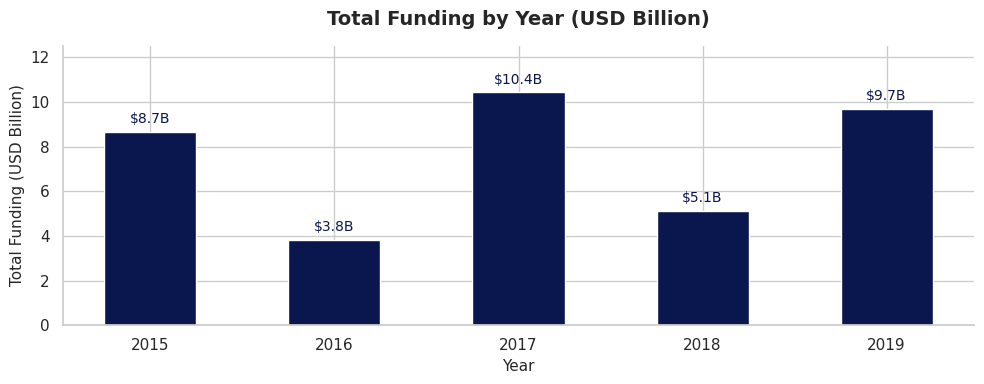

In [14]:
yearly = df.groupby('year')['amount_in_usd'].sum().reset_index()
yearly['funding_bn'] = yearly['amount_in_usd'] / 1e9

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(yearly['year'].astype(str), yearly['funding_bn'], color=NAVY, edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='$%.1fB', padding=4, fontsize=10, color=NAVY)
ax.set_title('Total Funding by Year (USD Billion)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Total Funding (USD Billion)', fontsize=11)
ax.set_ylim(0, yearly['funding_bn'].max() * 1.2)
sns.despine()
plt.tight_layout()
plt.show()

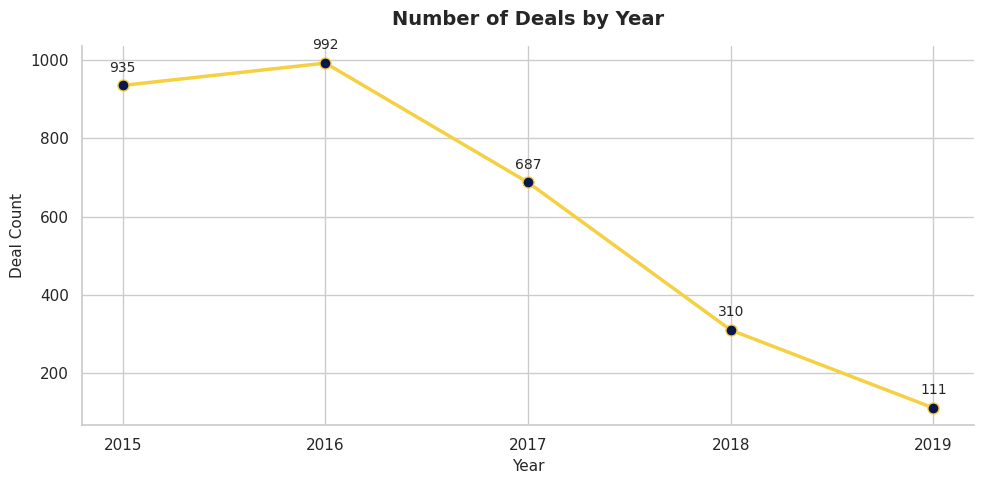

In [15]:
deal_count = df.groupby('year').size().reset_index(name='deals')

fig, ax = plt.subplots()
ax.plot(deal_count['year'].astype(str), deal_count['deals'],
        marker='o', color=GOLD, linewidth=2.5, markersize=8, markerfacecolor=NAVY)
for i, row in deal_count.iterrows():
    ax.annotate(str(row['deals']), (str(row['year']), row['deals']),
                textcoords="offset points", xytext=(0, 10), ha='center', fontsize=10)
ax.set_title('Number of Deals by Year', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Deal Count', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

### 📌 Insight
2017 recorded the highest total funding which is $10.4B, driven by small number of deals. Deal volume peaked in 2016, suggesting a shift toward higher frequency but smaller-sized rounds.

---
## Which month shows consistant most deals over years

In [16]:
monthly_deals = df.groupby(['year', 'month']).size().reset_index(name='no_of_deals')
max_month_per_year = monthly_deals.sort_values(['year', 'no_of_deals'], ascending=[True, False]).drop_duplicates('year')

max_month_per_year.style.hide(axis='index')

year,month,no_of_deals
2015,August,98
2016,January,104
2017,January,72
2018,February,42
2019,August,17


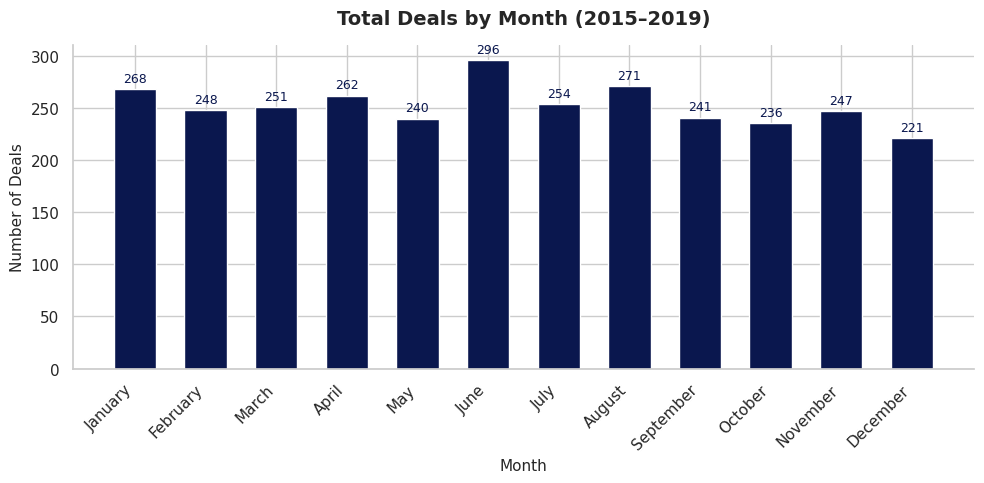

In [17]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_total = df.groupby('month').size().reset_index(name='deals')
monthly_total['month'] = pd.Categorical(monthly_total['month'], categories=month_order, ordered=True)
monthly_total = monthly_total.sort_values('month')

fig, ax = plt.subplots()
bars = ax.bar(monthly_total['month'], monthly_total['deals'],
              color=NAVY, edgecolor='white', width=0.6)
ax.bar_label(bars, padding=3, fontsize=9, color=NAVY)
ax.set_title('Total Deals by Month (2015–2019)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Number of Deals', fontsize=11)
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.tight_layout()
plt.show()

### 📌 Insight
June leads in total deal volume across all 5 years combined, but never 
ranks #1 in any single year — indicating consistent activity throughout 
the period. January and August show spike behavior, dominating in 
specific years but inconsistent overall. This suggests June is the most 
reliable month for deal flow, while Jan/Aug are driven by year-specific 
factors.

---
## Which is the highest funded startup every year?

In [18]:
idx = df.groupby('year')['amount_in_usd'].idxmax()
max_funding_per_year = df.loc[idx, ['year', 'startup_name', 'amount_in_usd']].reset_index(drop=True)
max_funding_per_year.columns = ['Year', 'Startup Name', 'Max Funding (USD)']
max_funding_per_year.style.hide(axis='index')

Year,Startup Name,Max Funding (USD)
2015,Flipkart,700000000
2016,Snapdeal,200000000
2017,Flipkart,2500000000
2018,True North,600000000
2019,Rapido Bike Taxi,3900000000


### 📌 Insight
Flipkart is highest funded startup twice, indicating that
a small number of late-stage deals account for a disproportionate share
of total capital deployed — a classic power law distribution in VC funding.

---
## Is there a growing sector or not, and which sector got the maximum funding across these 5 years? 

In [19]:
# Pivot table to see year-over-year growth for each industry
growth_comparison = df.groupby(['industry_vertical', 'year'])['amount_in_usd'].sum().unstack().fillna(0)
growth_comparison['Total'] = growth_comparison.sum(axis=1)
growth_comparison = growth_comparison.sort_values(by='Total', ascending=False).head(10)
growth_comparison.style.format(format_to_indian)

year,2015,2016,2017,2018,2019,Total
industry_vertical,,,,,,
E-Commerce,377.46 Cr,97.56 Cr,593.88 Cr,15.55 Cr,117.07 Cr,1201.51 Cr
Consumer Internet,13.94 Cr,193.80 Cr,260.87 Cr,201.72 Cr,61.44 Cr,731.77 Cr
Transport,72.59 Cr,0,0,40.00 Lakh,430.76 Cr,503.74 Cr
FinTech,43.09 Cr,3.17 Cr,54.91 Cr,129.25 Cr,153.01 Cr,383.42 Cr
SaaS & Enterprise Tech,45.67 Cr,68.35 Cr,98.19 Cr,89.97 Cr,62.37 Cr,364.55 Cr
Unclassified,133.94 Cr,0,0,0,0,133.94 Cr
HealthTech,29.77 Cr,5.24 Cr,11.60 Cr,24.00 Cr,50.30 Cr,120.91 Cr
Logistics,31.65 Cr,3.81 Cr,18.47 Cr,3.77 Cr,28.33 Cr,86.03 Cr
FoodTech,39.03 Cr,2.37 Cr,1.87 Cr,31.54 Cr,3.47 Cr,78.27 Cr


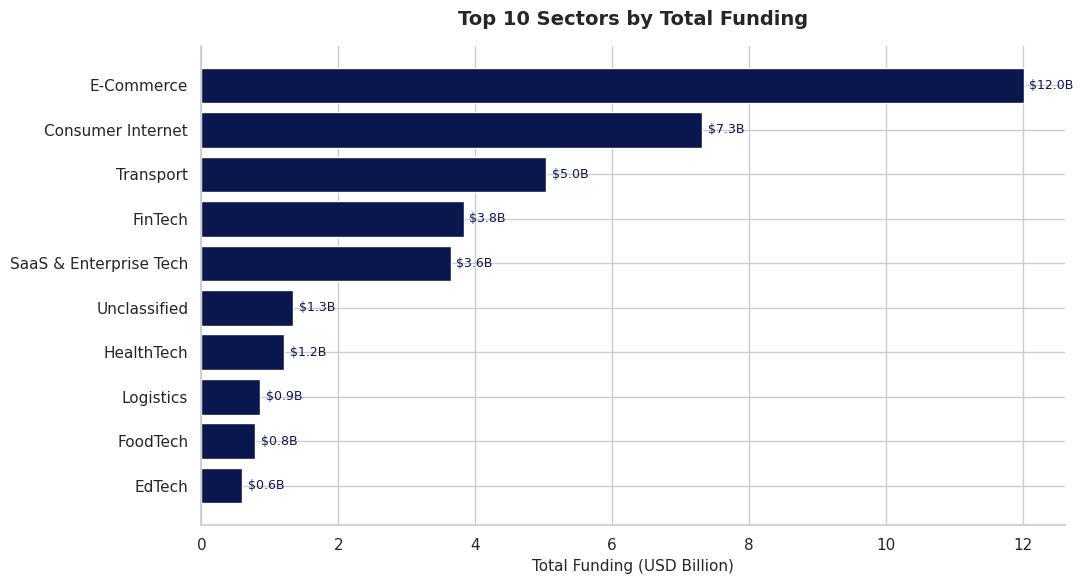

In [20]:
sector_funding = df.groupby('industry_vertical')['amount_in_usd'].sum()\
                   .sort_values(ascending=False).head(10).reset_index()
sector_funding['funding_bn'] = sector_funding['amount_in_usd'] / 1e9

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(sector_funding['industry_vertical'][::-1],
               sector_funding['funding_bn'][::-1], color=NAVY)
ax.bar_label(bars, fmt='$%.1fB', padding=4, fontsize=9, color=NAVY)
ax.set_title('Top 10 Sectors by Total Funding', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Funding (USD Billion)', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

### 📌 Insight
E- Commerce and Consumer Internet dominate total funding.
No single sector shows a clean linear growth trend means funding is lumpy
and deal-driven rather than sector-driven.

---
## Which city dominates funding ?


In [21]:
city_funding = df.groupby('city /state location').agg(
    total_funding=('amount_in_usd', 'sum'),
    no_of_deals=('startup_name', 'count')
).sort_values('total_funding', ascending=False).head(5)
city_funding.style.hide(axis='index')
city_funding.reset_index()

,city /state location,total_funding,no_of_deals
0,Bengaluru,18572950003,848
1,Mumbai,4945854620,570
2,Gurugram,3720065264,340
3,New Delhi,3300871515,459
4,Unknown,1716263868,197


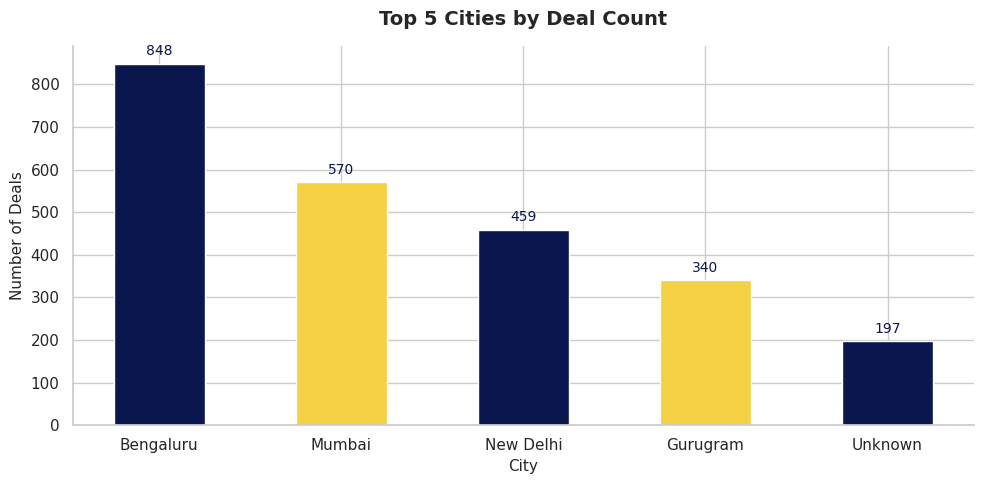

In [22]:
city_deals = df.groupby('city /state location').size()\
               .sort_values(ascending=False).head(5).reset_index(name='deals')

fig, ax = plt.subplots()
bars = ax.bar(city_deals['city /state location'], city_deals['deals'],
              color=[NAVY, GOLD, NAVY, GOLD, NAVY], edgecolor='white', width=0.5)
ax.bar_label(bars, padding=4, fontsize=10, color=NAVY)
ax.set_title('Top 5 Cities by Deal Count', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('City', fontsize=11)
ax.set_ylabel('Number of Deals', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

### 📌 Insight
Bangalore leads both in deal count and total funding followed by Mumbai,
Gurugram leaves past delhi in total funding but lacks in deal count. These four cities account for the majority of startup
activity, reflecting India's concentrated startup ecosystem.

---
## Who are the top most active Investors?

In [23]:
top_investors = df[df['investors_name'] != 'Undisclosed'].groupby('investors_name').size().reset_index(name='deal_count').sort_values('deal_count', ascending=False).head(10)
top_investors.reset_index(drop=True)

,investors_name,deal_count
0,Ratan Tata,25
1,Indian Angel Network,24
2,Kalaari Capital,16
3,Sequoia Capital,15
4,Group of Angel Investors,15
5,Accel Partners,12
6,Venture Catalysts,11
7,Brand Capital,11
8,SAIF Partners,10
9,RoundGlass Partners,10


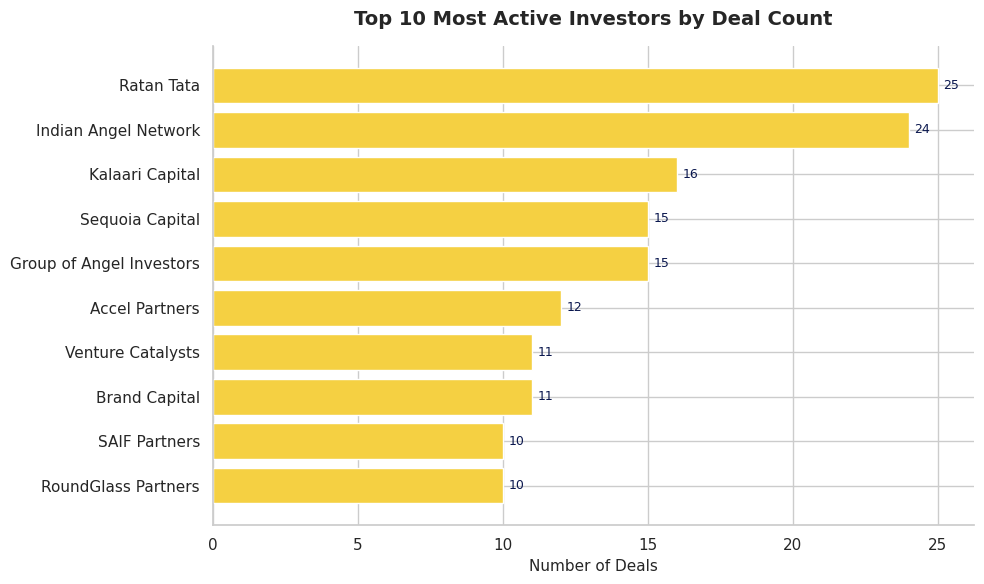

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_investors['investors_name'][::-1],
               top_investors['deal_count'][::-1], color=GOLD, edgecolor='white')
ax.bar_label(bars, padding=4, fontsize=9, color=NAVY)
ax.set_title('Top 10 Most Active Investors by Deal Count', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Deals', fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

### 📌 Insight
Ratan Tata being the most active investor with total 25 deals followed by Indian Angel Network.

---
## Which Investment Type Dominates?

In [25]:
inv_type = df.groupby('investment_type').agg(
    deal_count=('startup_name', 'count'),
    total_funding=('amount_in_usd', 'sum')
).sort_values('deal_count', ascending=False).head(10)
inv_type.reset_index()

,investment_type,deal_count,total_funding
0,Seed Funding,1529,1052682318
1,Private Equity,1359,26749248165
2,Debt Funding,28,176583174
3,Series A,23,194200000
4,Series B,19,4780836875
5,Series C,13,1036670000
6,Series D,12,1481799000
7,Angel Funding,11,1799205
8,Pre Series A,8,41372000
9,Unclassified,5,1207629011


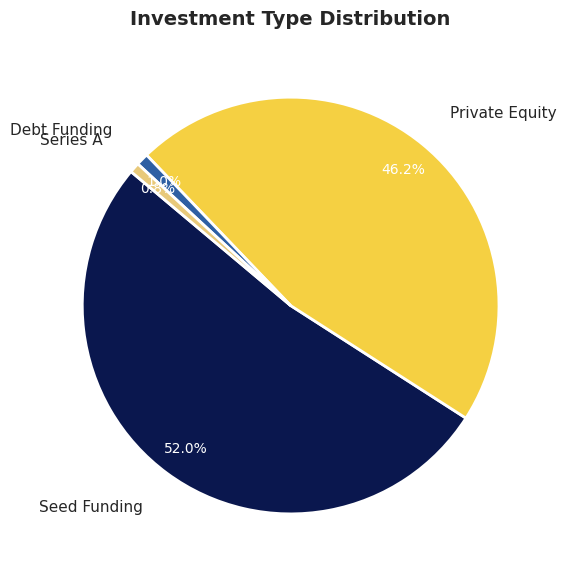

In [26]:
inv_dist = df['investment_type'].value_counts().head(4)

fig, ax = plt.subplots(figsize=(6, 6))
colors = [NAVY, GOLD, '#2E5FA3', '#E8C97A', '#4A7CC7', '#D4A843']
wedges, texts, autotexts = ax.pie(
    inv_dist.values, labels=inv_dist.index,
    autopct='%1.1f%%', colors=colors,
    startangle=140, pctdistance=0.85, labeldistance=1.2,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for text in autotexts:
    text.set_fontsize(10)
    text.set_color('white')
ax.set_title('Investment Type Distribution', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

### 📌 Insight
Private equity having the 2nd most no of deal and highest total funding. Seed funding, on the other hand despite of having highest no of deals
lacks in total funding which indicates high number of smaller deals.

In [27]:
df.to_csv('startup_funding_final.csv', index=False)
print("Exported successfully. Shape:", df.shape)

Exported successfully. Shape: (3035, 11)


---
## ✅ Key Takeaways

| Question | Finding |
|----------|---------|
| Peak funding year | 2017 |
| Most active year by deals | 2016 |
| Top city | Bangalore |
| Top sector | E-Commerce |
| Dominant investment type | Private Equity / Seed Funding |
| Most active investor | Ratan Tata with 25 deal counts|

---
*This notebook feeds into the Indian Startup Funding Power BI Dashboard —
see `powerbi/startup_dashboard.pbix` for the full interactive report.*